In [ ]:
# Rohith Kumar Senthil Kumar
# 5330 Computer Vision
# Project 3: Object Recognition and Classification
# PCA Visualization and Analysis


# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [43]:
df = pd.read_csv('features.csv', header=None)
resnet_df = pd.read_csv('resnet_features.csv', header=None)

In [44]:
df

,0,1,2,3,4,5,6,7,8,9
0,t-wrench,0.1713,0.5527,0.0487,0.5031,-0.1243,0.1843,0.2143,0.4364,2.1942
1,allen-key,0.2434,0.2599,-0.1816,-0.3187,0.2915,0.6646,1.1701,0.5921,-1.6044
2,mouse,0.7411,0.7521,0.7633,2.4935,4.0782,5.8616,11.1725,7.4256,10.8821
3,phone,0.8146,0.5390,0.6867,1.9122,3.4764,3.9682,7.6933,4.9247,-8.6347
4,pen,0.5010,0.1093,-0.2025,-0.3940,-0.2921,-0.2765,-0.5609,-0.4735,-3.1035
5,chisel,0.5054,0.1645,0.0284,0.0842,0.3595,0.3906,0.7656,0.4326,4.6314
6,pestle,0.6871,0.2256,0.2962,0.6492,1.8992,2.0281,3.9918,2.3549,5.7155
7,screwdriver,0.4989,0.1212,0.1936,0.4280,0.7374,0.7538,1.4994,0.9678,4.6966
8,candy,0.7961,0.5476,0.6006,1.6348,3.8989,4.1503,8.1829,4.9682,-8.8965
9,perfume,0.4370,0.5384,0.3360,1.1501,2.6388,1.9174,4.2356,2.5411,4.5821


In [35]:
resnet_df

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,512
0,mouse,0.1861,0.1996,0.5500,1.0774,0.0491,1.1707,2.9317,0.5062,0.4433,...,1.0747,1.6012,1.7991,0.8003,3.3395,0.0775,0.2794,0.4113,0.2753,0.1902
1,phone,0.1974,0.0955,0.0001,0.1019,0.0517,2.1132,2.3195,0.3985,0.2530,...,0.6179,0.9757,2.5421,0.2492,0.8834,1.2279,2.3310,0.3961,0.2847,0.6002
2,pen,0.1198,0.7558,0.0478,0.4220,0.1583,0.8629,1.4607,1.4925,1.9218,...,1.7549,0.7487,0.0459,0.3067,0.4600,0.0807,0.6608,2.9944,0.1326,0.8404
3,pestle,2.3765,1.0615,0.2666,0.7783,0.9247,0.0361,0.3610,1.9423,1.5216,...,0.3651,0.5991,0.4678,0.0100,0.0227,0.7582,0.1861,1.8728,1.9862,0.9986
4,screwdriver,0.2770,0.8831,0.1854,0.2377,0.2872,1.3218,0.9839,0.4607,1.3041,...,2.0934,0.3169,0.7582,0.0099,0.1016,0.4791,0.6409,1.7525,0.6213,0.2699
5,perfume,0.3725,0.8533,0.0439,0.2554,0.8166,0.4792,1.1448,0.4555,1.0637,...,0.4852,1.9002,1.1872,0.6675,0.7614,0.9024,1.2742,0.4913,0.1256,0.2329
6,scissors,1.7736,0.3517,0.5197,0.4874,0.6665,0.3816,0.3117,2.0612,1.5945,...,1.2655,0.6438,0.1082,0.1975,0.0688,0.0243,0.5483,0.0820,1.1864,1.3209
7,candy,0.1185,1.5250,0.0684,1.8096,1.4409,1.8020,0.7593,0.2611,0.5271,...,1.9480,0.2892,2.1082,0.2755,0.7610,0.7681,1.1339,0.5293,1.2687,1.4129
8,t-wrench,0.8748,0.2517,0.0815,0.6608,0.5622,0.2328,0.8439,0.1130,2.1667,...,1.4685,2.0559,0.2085,0.1465,0.0900,0.2596,0.3158,1.1899,1.2498,0.7803
9,allen-key,0.4702,0.1533,0.0003,0.4530,0.1556,1.0759,0.5199,0.2850,1.7177,...,1.0156,0.8248,0.4616,0.0254,0.0284,0.5189,0.1498,0.6280,0.0279,0.2044


In [36]:
data = df.values[:,1:]
resnet_data = resnet_df.values[:,1:]

In [12]:
data.shape

(12, 9)

In [37]:
resnet_data.shape

(12, 512)

In [ ]:
# typecast to float64 for PCA
data = data.astype(np.float64)
resnet_data = resnet_data.astype(np.float64)

In [ ]:
# normalize the data for PCA
data_norm = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
resnet_data_norm = (resnet_data - np.mean(resnet_data, axis=0)) / np.std(resnet_data, axis=0)

In [ ]:
# perform PCA on the normalized baseline data
pca1 = PCA(n_components=2)
pca1.fit(data_norm)
data_pca = pca1.transform(data_norm)

In [ ]:
# perform PCA on the normalized ResNet data
pca2 = PCA(n_components=2)
pca2.fit(resnet_data_norm)
resnet_data_pca = pca2.transform(resnet_data_norm)

In [ ]:
# extract labels for coloring the PCA plots
labels_1 = df.values[:,0]
labels_2 = resnet_df.values[:,0]

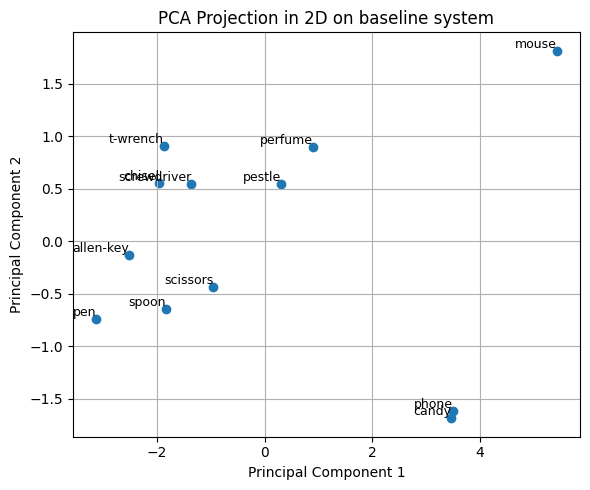

In [ ]:
# visualize the PCA projection for the baseline system
plt.figure(figsize=(6, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1])

# Annotate each point
for i, label in enumerate(labels_1):
    plt.text(data_pca[i, 0], data_pca[i, 1], label, fontsize=9, ha='right', va='bottom')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection in 2D on baseline system")
plt.grid(True)
plt.tight_layout()
plt.show()

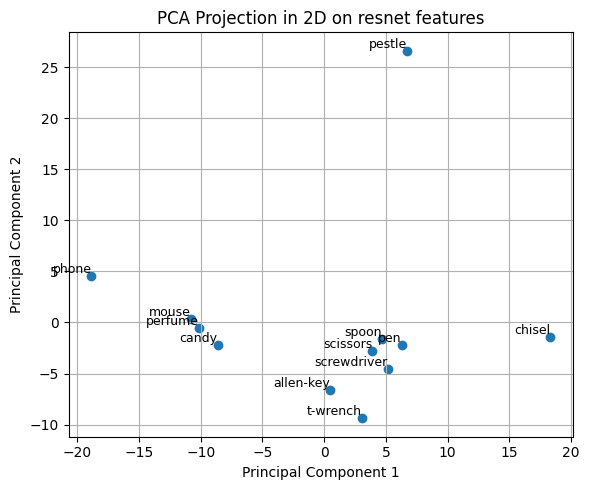

In [ ]:
# visualize the PCA projection for the ResNet features
plt.figure(figsize=(6, 5))
plt.scatter(resnet_data_pca[:, 0], resnet_data_pca[:, 1])

# Annotate each point
for i, label in enumerate(labels_2):
    plt.text(resnet_data_pca[i, 0], resnet_data_pca[i, 1], label, fontsize=9, ha='right', va='bottom')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection in 2D on resnet features")
plt.grid(True)
plt.tight_layout()
plt.show()